# Corporate Credit Risk Modeling Using Credit Ratings

Project Overview

This project is to develop a corporate credit risk model to estimate the probability of high default risk using credit rating information as a proxy target variable. Logistic Regression Model is implemented and evaluated using standard credit risk validation metrics such as AUC, Gini coefficient, KS statistic, and PSI. Threshold optimization is performed to improve the identification of high-risk companies. The model outputs are further used to estimate Expected Loss and analyze portfolio risk under different stress scenarios.

### Table Of Contents

Target Variable already Defined as Default_risk_indicator. For more Information, Please refer to the **"Data Preprocessing.ipynb"** notebook

1. [Calculation of WoE and IV using OptimalBinning](#Calculation-of-WoE-and-IV-using-OptimalBinning)
2. [Model Construction and Evaluation](#Model-Construction-and-Evaluation)
   - 2.1 [Logistic Regression](#Logistic-Regression)
   - 2.2 [Precision, Recall and Threshold Analysis](#Precision,-Recall-and-Threshold-Analysis)
   - 2.3 [Confusion Matrix](#Confusion-Matrix)
   - 2.4 [ROC Curve and AUC](#ROC-Curve-and-AUC)
3. [Model Validation metrics](#Model-Validation-metrics)
   - 3.1 [KS Statistic](#KS-Statistic)
   - 3.2 [Gini Coefficient](#Gini-Coefficient)
   - 3.3 [Population Stability Index (PSI)](#Population-Stability-Index-(PSI))
4. [Coefficients Interpretation](#Coefficients-Interpretation)
   - 4.1 [Sector Coefficient Breakdown](#Sector-Coefficient-Breakdown)
5. [Expected Loss Calculation](#Expected-Loss-Calculation)
   - 5.1[Expected Loss sectoral analysis](#Expected-Loss-sectoral-analysis)
6. [Stress Testing](#Stress-Testing)
   - 6.1 [Expected Loss Distribution in Baseline and Stress Scenarios](#Expected-Loss-Distribution-in-Baseline-and-Stress-Scenarios)
   - 6.2 [Expected Loss Migration Matrix](#Expected-Loss-Migration-Matrix)
   - 6.3 [Top Borrowers with Largest Expected Loss Increase](#Top-Borrowers-with-Largest-Expected-Loss-Increase)
   - 6.4 [Sector-wise EL change under Stress](#Sector-wise-EL-change-under-Stress)
7. [Model Conclusion](#Model-Conclusion)


In [2]:
# Operational libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from optbinning import OptimalBinning

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling libraries
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as metrics
from scipy.stats import ks_2samp

pd.set_option('display.max_columns', None)

In [3]:
# Reading data which has been preprocessed
imported_data = pd.read_csv('cleaned_data.csv')

In [4]:
# Creating customized index for Accurate merging of output data

imported_data['ID'] = imported_data['Symbol'] + '_' + imported_data['year'].astype(str)
imported_data = imported_data.set_index('ID')

In [5]:
imported_data.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,year,Rating_score,Default_risk_indicator,LGD_proxy,EAD_proxy,previous_rating,Rating_downgrade
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MMM_2012,AA,3M Company,MMM,Moody's Investors Service,2012-06-15,Health Care,2.249586,1.387061,0.407829,47.666577,0.144642,0.203674,0.470028,0.208639,0.135469,0.230411,0.277756,0.936583,3.862640,1.050324,0.512272,0.277566,0.739023,5.511644,5.194072,2.050324,0.203674,8.743916,7.458010,0.178447,9.551430,2012,9,0,0.512272,0.444526,0.0,0
MMM_2013,AA,3M Company,MMM,Egan-Jones Ratings Company,2013-08-16,Health Care,1.698186,1.012270,0.344225,50.284895,0.150918,0.212562,0.478281,0.215931,0.138867,0.251881,0.266198,0.920149,3.568077,0.916924,0.478331,0.280555,0.713770,6.088869,4.893679,1.916924,0.212562,11.290941,8.530576,0.188429,8.952752,2013,9,0,0.478331,0.588864,9.0,0
MMM_2015,AA,3M Company,MMM,Egan-Jones Ratings Company,2015-01-28,Health Care,1.961487,1.127209,0.316272,48.611609,0.155746,0.220798,0.483140,0.224223,0.158496,0.278026,0.378061,1.017653,3.748498,1.385308,0.580767,0.288642,0.774676,7.906654,3.886322,2.385308,0.220798,12.911759,10.206408,0.208227,9.101826,2015,9,0,0.580767,0.509817,9.0,0
ABB_2012,A,ABB Ltd,ABB,Moody's Investors Service,2012-06-15,Consumer Durables,1.436326,0.300405,0.290985,0.000000,0.087260,0.119768,0.300974,0.000237,0.083611,0.197081,0.210116,0.958182,7.718407,1.477594,0.587974,0.000000,0.986988,1.558129,2.174388,2.513025,0.119768,43.555179,1.578671,0.095078,5.545208,2012,8,0,0.587974,0.696221,0.0,0
ABB_2013,A,ABB Ltd,ABB,Egan-Jones Ratings Company,2013-08-05,Consumer Durables,1.584708,0.372894,0.361079,0.000000,0.069466,0.097161,0.286561,0.104832,0.060482,0.129536,0.155638,0.870672,6.691398,1.544919,0.600366,0.000000,0.995073,1.582499,2.707009,2.573295,0.097161,9.225518,1.590335,0.087292,5.840376,2013,8,0,0.600366,0.631031,8.0,0


In [6]:
data = imported_data.copy()

In [7]:
# Train test split
train = data[data['year'] < 2016].drop(['Rating',  'Name', 'Symbol', 'Rating Agency Name', 'Date', 'debtRatio', 'freeCashFlowPerShare', 'pretaxProfitMargin', 'operatingProfitMargin', 'ebitPerRevenue', 'currentRatio', 'LGD_proxy', 'EAD_proxy', 'previous_rating', 'Rating_score', 'year'], axis=1)
test = data[data['year'] == 2016].drop(['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'debtRatio', 'freeCashFlowPerShare', 'pretaxProfitMargin', 'operatingProfitMargin', 'ebitPerRevenue', 'currentRatio', 'LGD_proxy', 'EAD_proxy', 'previous_rating', 'Rating_score', 'year'], axis=1)

In [8]:
x_train = train.drop('Default_risk_indicator', axis=1)
y_train = train['Default_risk_indicator']
x_test = test.drop('Default_risk_indicator', axis=1)
y_test = test['Default_risk_indicator']

# **Calculation of WoE and IV using OptimalBinning**

In [9]:
# using binning library to create woe and IV

bin_models = {}

for col in x_train.columns:

    if x_train[col].dtype in ["int64","float64"]:
        optb = OptimalBinning(name=col, dtype="numerical")
    else:
        optb = OptimalBinning(name=col, dtype="categorical")

    optb.fit(x_train[col], y_train)

    bin_models[col] = optb

In [10]:
# Def function for transform data to woe

def transform_woe(data, bin_models):

    woe_data = pd.DataFrame(index=data.index)

    for col, model in bin_models.items():

        if col not in data.columns:
            print(f"Skipping missing column: {col}")
            continue

        woe_data[col] = model.transform(data[col], metric="woe")

    return woe_data

In [11]:
x_train_woe = transform_woe(x_train, bin_models)
x_test_woe = transform_woe(x_test, bin_models)

In [12]:
# Exporting File to Excel
with pd.ExcelWriter("binning_tables.xlsx") as writer:
    for col, model in bin_models.items():
        bt = model.binning_table.build()
        bt.to_excel(writer, sheet_name=col[:31], index=False)

In [13]:
# Selecting IV value theshold of 0.2 for model
selected_vars = []

for col, model in bin_models.items():
    if model.binning_table.iv >= 0.2:
        selected_vars.append(col)

In [14]:
#Filtering data for model based on Information Value(IV)

x_train_final = x_train_woe[selected_vars]
x_test_final = x_test_woe[selected_vars]

# **Model Construction and Evaluation**

### Logistic Regression

In [15]:
# Logistic Regression
model = LogisticRegression(max_iter=100, solver='liblinear', penalty='l2', C=0.1, class_weight='balanced', random_state=42)

model.fit(x_train_final, y_train)
y_pred = model.predict(x_test_final)
y_prob = model.predict_proba(x_test_final)[:,1]

print(metrics.confusion_matrix(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("ROC AUC:", metrics.roc_auc_score(y_test, y_prob))

[[124  42]
 [ 53 120]]
              precision    recall  f1-score   support

           0       0.70      0.75      0.72       166
           1       0.74      0.69      0.72       173

    accuracy                           0.72       339
   macro avg       0.72      0.72      0.72       339
weighted avg       0.72      0.72      0.72       339

Accuracy: 0.7197640117994101
ROC AUC: 0.8053833832439585


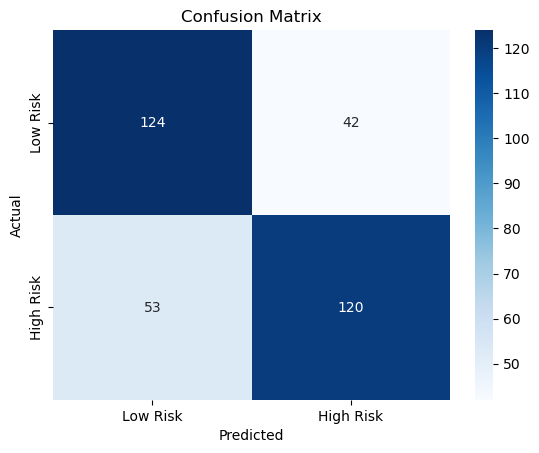

In [16]:
cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

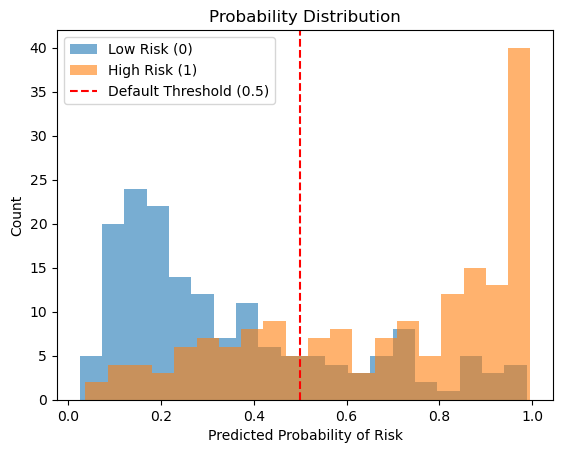

In [17]:
# Logistic Regression Probability Distribution

y_prob = model.predict_proba(x_test_final)[:, 1]

plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Low Risk (0)")
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="High Risk (1)")

plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.legend()
plt.xlabel("Predicted Probability of Risk")
plt.ylabel("Count")
plt.title("Probability Distribution")
plt.show()


probability Distribution graph shows there is an overlaps between approximately 0.35 and 0.65, where both low-risk and high-risk companies appear. Since, this a credit risk model, we want to identify the high risk companies and reduce the default risk. we will exploring the threshold adjustment between 0.35 and 0.5 to identify high risk companies

### Precision, Recall and Threshold Analysis

In [18]:
# Threshold calculation
y_prob = model.predict_proba(x_test_final)[:, 1]

precision, recall, thresholds = metrics.precision_recall_curve(
    y_test,
    y_prob,
    pos_label=1
)

threshold_analysis = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

# Calculate accuracy for each threshold
accuracies = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    acc = metrics.accuracy_score(y_test, y_pred)
    accuracies.append(acc)

threshold_analysis["Accuracy"] = accuracies


In [19]:
threshold_analysis[
    (threshold_analysis["Threshold"] >= 0.30) & (threshold_analysis["Threshold"] <= 0.50)
    ]


,Threshold,Precision,Recall,Accuracy
117,0.300905,0.680180,0.872832,0.725664
118,0.307894,0.683258,0.872832,0.728614
119,0.310502,0.681818,0.867052,0.725664
120,0.313515,0.684932,0.867052,0.728614
121,0.315649,0.683486,0.861272,0.725664
122,0.317394,0.686636,0.861272,0.728614
123,0.317526,0.685185,0.855491,0.725664
124,0.318829,0.688372,0.855491,0.728614
125,0.320345,0.686916,0.849711,0.725664
126,0.325500,0.690141,0.849711,0.728614


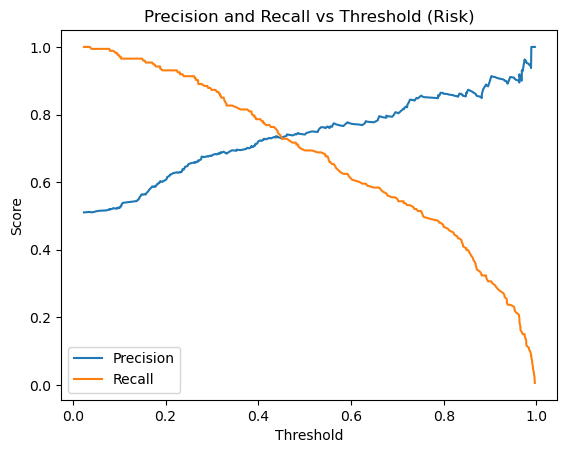

In [20]:
# Plotting Precision and Recall vs Threshold
plt.plot(thresholds, precision[:-1])
plt.plot(thresholds, recall[:-1])

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold (Risk)")
plt.legend(["Precision", "Recall"])
plt.show()

As shown in the plot, the optimal threshold range lies between 0.30 and 0.50, where the model achieves a balanced trade-off between precision and recall. Since the objective of a credit risk model is to effectively identify high-risk companies, we select a threshold that provides the highest accuracy while maintaining recall close to 0.8, ensuring that most risky borrowers are correctly detected.

In [21]:
# As per the graph, the optimal threshold is 0.38

y_prob = model.predict_proba(x_test_final)[:, 1]

y_pred = np.where(y_prob >= 0.38, 1, 0)

print(metrics.confusion_matrix(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))
print(f'Accuracy---', metrics.accuracy_score(y_test, y_pred))
print(f'ROC_AUC Score---', metrics.roc_auc_score(y_test, y_prob))

[[106  60]
 [ 33 140]]
              precision    recall  f1-score   support

           0       0.76      0.64      0.70       166
           1       0.70      0.81      0.75       173

    accuracy                           0.73       339
   macro avg       0.73      0.72      0.72       339
weighted avg       0.73      0.73      0.72       339

Accuracy--- 0.7256637168141593
ROC_AUC Score--- 0.8053833832439585


## Confusion Matrix

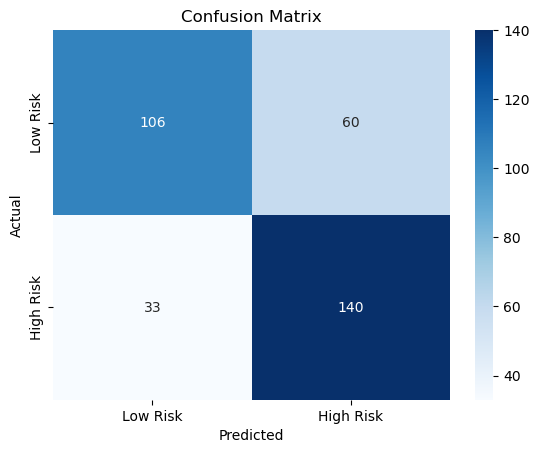

In [22]:
cm = metrics.confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk','High Risk'],
            yticklabels=['Low Risk','High Risk'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

The Confusion Matrix shows our Model able to predict 81% of the high risk companies correctly which shows strong ability to identify high risk companies while incorrectly classifies 36% of the low risk companies as high risk.

### ROC Curve and AUC

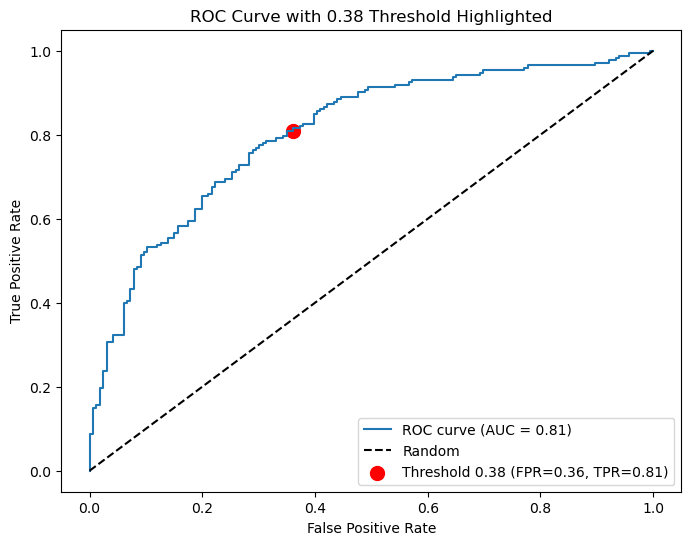

In [23]:
# ROC_AUC Curve

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob, pos_label=1)
roc_auc = metrics.auc(fpr, tpr)

# Find the index of the threshold closest to 0.38
idx = np.argmin(np.abs(thresholds - 0.38))

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')

# Highlight the 0.38 threshold point
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, label=f'Threshold 0.38 (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with 0.38 Threshold Highlighted')
plt.legend()
plt.show()

In [24]:
# Adding the predicted probabilities to the original data
x_train_PD_data = x_train.copy()
x_test_PD_data = x_test.copy()

x_train_PD_data['PD_prob'] = model.predict_proba(x_train_final)[:,1]
x_test_PD_data['PD_prob']  = model.predict_proba(x_test_final)[:,1]

In [25]:
# Combining the train and test data to create a single dataframe and adding the predicted probabilities
combined_train_test = pd.concat([x_train_PD_data, x_test_PD_data], axis=0).sort_index()

# Imported_data is raw dataset before transformation
combined_pd = imported_data.join(combined_train_test[['PD_prob']], how='left')

combined_pd.to_csv('PD_Model_Data.csv', index=False)

In [26]:
combined_pd.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,year,Rating_score,Default_risk_indicator,LGD_proxy,EAD_proxy,previous_rating,Rating_downgrade,PD_prob
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MMM_2012,AA,3M Company,MMM,Moody's Investors Service,2012-06-15,Health Care,2.249586,1.387061,0.407829,47.666577,0.144642,0.203674,0.470028,0.208639,0.135469,0.230411,0.277756,0.936583,3.862640,1.050324,0.512272,0.277566,0.739023,5.511644,5.194072,2.050324,0.203674,8.743916,7.458010,0.178447,9.551430,2012,9,0,0.512272,0.444526,0.0,0,0.032305
MMM_2013,AA,3M Company,MMM,Egan-Jones Ratings Company,2013-08-16,Health Care,1.698186,1.012270,0.344225,50.284895,0.150918,0.212562,0.478281,0.215931,0.138867,0.251881,0.266198,0.920149,3.568077,0.916924,0.478331,0.280555,0.713770,6.088869,4.893679,1.916924,0.212562,11.290941,8.530576,0.188429,8.952752,2013,9,0,0.478331,0.588864,9.0,0,0.031591
MMM_2015,AA,3M Company,MMM,Egan-Jones Ratings Company,2015-01-28,Health Care,1.961487,1.127209,0.316272,48.611609,0.155746,0.220798,0.483140,0.224223,0.158496,0.278026,0.378061,1.017653,3.748498,1.385308,0.580767,0.288642,0.774676,7.906654,3.886322,2.385308,0.220798,12.911759,10.206408,0.208227,9.101826,2015,9,0,0.580767,0.509817,9.0,0,0.063487
ABB_2012,A,ABB Ltd,ABB,Moody's Investors Service,2012-06-15,Consumer Durables,1.436326,0.300405,0.290985,0.000000,0.087260,0.119768,0.300974,0.000237,0.083611,0.197081,0.210116,0.958182,7.718407,1.477594,0.587974,0.000000,0.986988,1.558129,2.174388,2.513025,0.119768,43.555179,1.578671,0.095078,5.545208,2012,8,0,0.587974,0.696221,0.0,0,0.535565
ABB_2013,A,ABB Ltd,ABB,Egan-Jones Ratings Company,2013-08-05,Consumer Durables,1.584708,0.372894,0.361079,0.000000,0.069466,0.097161,0.286561,0.104832,0.060482,0.129536,0.155638,0.870672,6.691398,1.544919,0.600366,0.000000,0.995073,1.582499,2.707009,2.573295,0.097161,9.225518,1.590335,0.087292,5.840376,2013,8,0,0.600366,0.631031,8.0,0,0.605601


# **Model Validation metrics**

### Gini Coefficient

In [27]:
# Gini Coefficient
y_prob = model.predict_proba(x_test_final)[:,1]
auc = metrics.roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
print(f'Gini Coefficient---', gini)

Gini Coefficient--- 0.6107667664879171


### KS Statistic

In [28]:
# KS Statistic
ks_statistic, p_value = ks_2samp(
    y_prob[y_test == 1],
    y_prob[y_test == 0]
)

print(f"KS Statistic: {ks_statistic}")
print(f"p-value: {p_value:.4f}")

KS Statistic: 0.4740929034055296
p-value: 0.0000


### Population Stability Index (PSI)

In [29]:
# PSI calculation for model output
def calculate_psi(expected, actual, buckets=10):
    
    breakpoints = np.percentile(expected, np.arange(0, 100 + 100/buckets, 100/buckets))
    
    expected_counts = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, breakpoints)[0] / len(actual)
    
    psi_values = (actual_counts - expected_counts) * np.log((actual_counts + 1e-6) / (expected_counts + 1e-6))
    
    return np.sum(psi_values)

In [30]:
psi = calculate_psi(x_train_PD_data['PD_prob'], x_test_PD_data['PD_prob'])

print("PSI:", psi)

PSI: 0.04499340506841234


In [31]:
# Evaluation Metrics

Evaluation_Metrics = {
    'AUC': roc_auc,
    'Gini Coefficient': gini,
    'KS Statistic': ks_statistic,
    'PSI': psi
}

pd.DataFrame(Evaluation_Metrics, index=['Value'])

,AUC,Gini Coefficient,KS Statistic,PSI
Value,0.805383,0.610767,0.474093,0.044993


**Model Validation Metrics**

**AUC (0.805) / Gini (0.611)**: The model have strong ability to classify corporate borrowers from low risk to high risk Effectively.

**KS (0.474)**: This metrics indicates that the model clearly separates High Default risk and low default risk corporate borrowers.

**PSI (0.045)**: The corporate portfolio distribution is stable, indicating no significant data drift from the training to the test set.

# **Coefficients Interpretation**

In [32]:
coef_df = pd.DataFrame({
    "Variable": x_train_final.columns,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

,Variable,Coefficient
0,netProfitMargin,-0.004007
1,returnOnCapitalEmployed,-0.173064
2,returnOnEquity,-0.202654
3,enterpriseValueMultiple,-0.252060
4,effectiveTaxRate,-0.264667
5,freeCashFlowOperatingCashFlowRatio,-0.310793
6,grossProfitMargin,-0.334558
7,companyEquityMultiplier,-0.383573
8,debtEquityRatio,-0.394414
9,returnOnAssets,-0.432155


# Coefficent Interpretation

Cash Ratio (-0.874) and Operating Cash Flow to Sales Ratio (-0.642): Higher liquidity and stronger cash flow from sales significantly reduce the probability of high default risk, indicating financially stable firms are less likely to fall into distressed credit ratings.

Sector (-0.612) and Operating Cash Flow per Share (-0.474): Default risk varies across industries, and companies generating stronger cash flow per share are less likely to be classified in high default-risk rating categories.

Return on Assets (-0.432) and Debt-Equity Ratio (-0.394): Firms that utilize their assets efficiently and maintain healthier capital structures tend to have lower chances of being rated in high default-risk categories.

Gross Profit Margin (-0.335) and Free Cash Flow to Operating Cash Flow Ratio (-0.311): Higher profitability and better cash flow conversion reduce the likelihood of firms falling into high default-risk rating groups rather than actual default events.

In [33]:
# Sector breakdown

sector_coef = -0.612487

sector_bt = bin_models['Sector'].binning_table.build()

sector_bt['WoE'] = pd.to_numeric(sector_bt['WoE'], errors='coerce')

sector_bt['Coefficient'] = sector_coef * sector_bt['WoE']

sector_bt = sector_bt.sort_values(by='Coefficient', ascending=False)

sector_bt

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Coefficient
8,[Consumer Services],157,0.122465,65,92,0.585987,-0.690831,0.059595,7.304688e-03,0.423125
7,[Basic Industries],169,0.131825,76,93,0.550296,-0.545296,0.040068,4.947310e-03,0.333987
6,"[Technology, Consumer Durables]",194,0.151326,105,89,0.458763,-0.178106,0.004861,6.068333e-04,0.109087
5,"[Energy, Transportation]",221,0.172387,129,92,0.416290,-0.005406,0.000005,6.300090e-07,0.003311
9,Special,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000e+00,-0.000000
10,Missing,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000e+00,-0.000000
4,[Capital Goods],148,0.115445,87,61,0.412162,0.011605,0.000016,1.941350e-06,-0.007108
3,[Health Care],107,0.083463,69,38,0.355140,0.253091,0.005206,6.490730e-04,-0.155015
2,"[Finance, Miscellaneous]",68,0.053042,47,21,0.308824,0.462195,0.010720,1.328160e-03,-0.283089
1,[Consumer Non-Durables],85,0.066303,66,19,0.223529,0.901786,0.047151,5.701892e-03,-0.552332


## Sector Coefficient Breakdown


**High Risk Sectors**
Consumer Services: Firms in this sector show a higher likelihood of falling into high default-risk rating categories because revenues depend heavily on discretionary consumer spending, which declines during economic downturns.

Basic Industries: Companies in this sector tend to have higher default-risk ratings due to their strong dependence on commodity price cycles and overall economic conditions.

Technology & Consumer Durables: Firms in these sectors show slightly higher default-risk classification because demand for technology products and durable goods is cyclical and sensitive to consumer purchasing power.

**Low Risk Sectors**

Public Utilities: Companies in this sector are less likely to fall into high default-risk rating groups because they typically operate with stable and regulated revenue streams.

Consumer Non-Durables: Firms producing essential goods show lower default-risk ratings since demand for necessities remains relatively stable even during economic downturns.

Finance & Miscellaneous: Firms in these sectors tend to have lower default-risk classification as financial institutions often maintain stricter capital requirements and liquidity management practices.

In [34]:
# This explains the impact of netProfitMargin
data.groupby('Sector')['netProfitMargin'].agg(['mean', 'std'])

,mean,std
Sector,,
Basic Industries,0.001520,0.261298
Capital Goods,0.044985,0.326284
Consumer Durables,0.049214,0.032056
Consumer Non-Durables,0.069904,0.054320
Consumer Services,0.091698,0.241474
Energy,0.633344,15.586316
Finance,0.143603,0.330239
Health Care,0.049821,0.251504
Miscellaneous,0.104189,0.097580


Although net profit margin normally reduces default risk, the model shows the opposite sign in this dataset. This happens because some sectors have extremely volatile profit margins, which confuses the relationship between profitability and default.
Especially Energy **(standard deviation of 15.59)** and Utilities **(std 8.63)**, which are very volatile thus confused confuses the relationship between profitability and default.

# **Expected Loss Calculation**

In [35]:
# Importing CSV

El_calc = pd.read_csv('PD_Model_Data.csv')

In [36]:
El_calc['Expected_Loss_percentage'] = El_calc['PD_prob'] * El_calc['LGD_proxy'] * El_calc['EAD_proxy'] * 100

In [37]:
El_calc_latest = (El_calc[El_calc['year'] == 2016])

In [38]:
sector_year_el = (
    El_calc.pivot_table(
        values='Expected_Loss_percentage',
        index='Sector',
        columns='year',
        aggfunc='mean'
    )
)

sector_year_el = sector_year_el.sort_values(2016, ascending=False)

sector_year_el.style.background_gradient().format("{:.2f}")

year,2011,2012,2013,2014,2015,2016
Sector,,,,,,
Consumer Durables,nan,28.26,27.81,25.02,25.71,43.73
Energy,22.78,18.07,22.85,22.53,27.26,38.23
Consumer Services,17.61,25.56,34.86,28.96,28.57,30.86
Technology,17.35,21.51,18.39,21.78,19.43,23.69
Public Utilities,14.41,17.08,19.32,16.78,17.97,22.67
Miscellaneous,nan,22.21,10.26,13.40,14.58,22.36
Capital Goods,15.12,19.17,13.17,16.20,18.44,17.67
Health Care,32.46,7.14,14.65,20.53,18.87,17.51
Basic Industries,34.97,15.33,18.57,20.68,19.57,17.24


## Expected Loss sectoral analysis

Sectoral variation: Expected loss differs widely across sectors over time, indicating that credit risk exposure is not uniform across industries.

Trend over time - Several sectors show noticeable fluctuations between 2011–2016, suggesting that sector risk changes with economic and market conditions.

2016 risk spike: In 2016, sectors such as Consumer Durables (43.73) and Energy (38.23) recorded the highest expected losses, indicating a significant rise in credit risk during that year.

In [39]:
year_components = El_calc.groupby('year')[
    ['PD_prob','LGD_proxy','EAD_proxy','Expected_Loss_percentage']
].mean()

year_components

,PD_prob,LGD_proxy,EAD_proxy,Expected_Loss_percentage
year,,,,
2011,0.484521,0.625335,0.716135,20.175228
2012,0.450847,0.631232,0.648290,18.548498
2013,0.454754,0.642384,0.654711,20.160892
2014,0.475525,0.642097,0.647977,20.261432
2015,0.473111,0.655252,0.667997,21.108212
2016,0.515825,0.675243,0.679460,24.427946


<Axes: xlabel='year'>

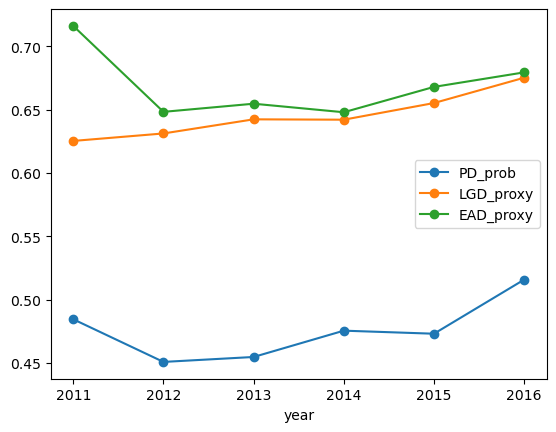

In [40]:
year_components[['PD_prob','LGD_proxy','EAD_proxy']].plot(marker='o')

In [41]:

year_components_grp = El_calc_latest.groupby(['Sector'])[
    ['PD_prob','LGD_proxy','EAD_proxy','Expected_Loss_percentage']
].mean().sort_values('Expected_Loss_percentage', ascending=False)

year_components_grp

,PD_prob,LGD_proxy,EAD_proxy,Expected_Loss_percentage
Sector,,,,
Consumer Durables,0.600734,0.784722,0.849464,43.729151
Energy,0.737538,0.644440,0.767286,38.232561
Consumer Services,0.579834,0.685090,0.725577,30.862587
Technology,0.491965,0.646853,0.655562,23.691208
Public Utilities,0.338471,0.703645,0.915951,22.674113
Miscellaneous,0.417815,0.798697,0.662356,22.360817
Capital Goods,0.462914,0.667713,0.552287,17.668942
Health Care,0.394879,0.648816,0.616641,17.510262
Basic Industries,0.607150,0.628125,0.484052,17.240729


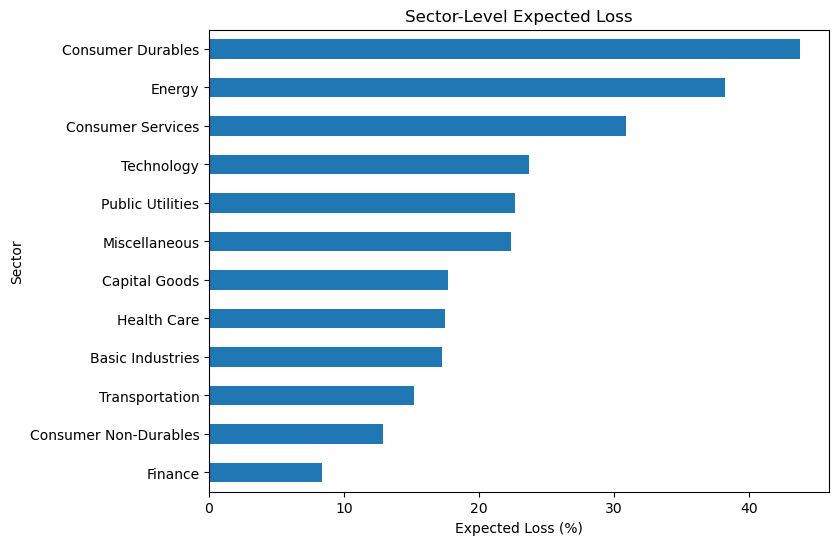

In [42]:
year_components_grp['Expected_Loss_percentage'].sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.xlabel("Expected Loss (%)")
plt.ylabel("Sector")
plt.title("Sector-Level Expected Loss")
plt.show()

Consumer Durables and Energy show the highest default-risk exposure, driven by very high probabilities of default (PD ≈ 0.60 and 0.74 respectively) along with relatively high LGD and EAD, indicating a greater likelihood of firms falling into high default-risk rating categories with substantial potential loss exposure.

Consumer Services, Technology, Public Utilities, and Miscellaneous represent moderate default-risk sectors, where moderate PD together with considerable LGD and EAD leads to noticeable potential credit losses.

Finance, Consumer Non-Durables, Transportation, Health Care, Capital Goods, and Basic Industries show comparatively lower default-risk exposure, mainly due to lower PD levels, although LGD and EAD still contribute to potential losses if firms move into distressed rating categories.

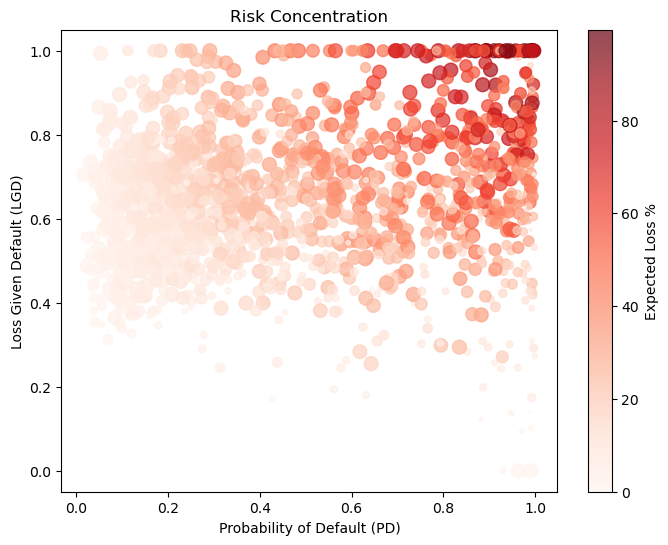

In [43]:
# Bubble Plot for PD and LGD Concentration
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    El_calc['PD_prob'],
    El_calc['LGD_proxy'],
    s=El_calc['EAD_proxy']*100,
    c=El_calc['Expected_Loss_percentage'],
    cmap='Reds',
    alpha=0.7
)

plt.colorbar(scatter, label="Expected Loss %")

plt.xlabel("Probability of Default (PD)")
plt.ylabel("Loss Given Default (LGD)")
plt.title("Risk Concentration")

plt.show()

The scatter plot shows that not all companies with high Loss Given Default (LGD) have a high Probability of Default (PD). While some firms showss both high PD and high LGD, many firms with high LGD are associated with lower PD values, indicating that severity of loss and likelihood of default do not always increase together.

# **Stress Testing**

In [44]:
stress_data = x_test.copy()  # Test Data Contains only year 2016 Data

# We will take key ratios for stress testing by increasing them to see how it affects PD and EL
stress_data['cashRatio'] *= 0.75  # Reduced to increase liquidity pressure
stress_data['returnOnAssets'] *= 0.60 # to show less profitability
stress_data['effectiveTaxRate'] *= 1.3 # to show higher tax rate

stress_x_test_woe = transform_woe(stress_data, bin_models)

stress_x_test_woe = stress_x_test_woe[model.feature_names_in_]

x_test_woe = x_test_woe[model.feature_names_in_]

pd_baseline = model.predict_proba(x_test_woe)[:,1]
pd_stress = model.predict_proba(stress_x_test_woe)[:,1]

In [45]:
print(x_test.columns)
print(stress_data.columns)

Index(['Sector', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'grossProfitMargin', 'returnOnAssets',
       'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover',
       'fixedAssetTurnover', 'debtEquityRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'cashPerShare',
       'companyEquityMultiplier', 'enterpriseValueMultiple',
       'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio',
       'payablesTurnover', 'Rating_downgrade'],
      dtype='object')
Index(['Sector', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'grossProfitMargin', 'returnOnAssets',
       'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover',
       'fixedAssetTurnover', 'debtEquityRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'cashPerShare',
       'companyEquityMultiplier', 'enterpriseValueMultiple',
       'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio',
       '

In [46]:
# Creating Dataframe for PD and EL

results = pd.DataFrame({
    'ID': stress_data.index,
    "PD_baseline": pd_baseline,
    "PD_stress": pd_stress,
    'EL_baseline': El_calc_latest['Expected_Loss_percentage'],
}).set_index("ID")

In [47]:
stress_data_results = stress_data.join(results)
Ead_lgd = data.loc[data['year'] == 2016, ['EAD_proxy','LGD_proxy']]

print(f"EAD and LGDE :", Ead_lgd.value_counts().sum())
print(f"Stress Data :", stress_data_results.value_counts().sum())

EAD and LGDE : 339
Stress Data : 339


In [48]:
# Joining all necessary data for stress testing

stress_data_results = stress_data_results.join(Ead_lgd)

In [49]:
# Stress testing data components calculation

stress_data_results['Stressed_EL'] =  stress_data_results['EAD_proxy'] * stress_data_results['LGD_proxy'] * stress_data_results['PD_stress'] * 100
stress_data_results["Stressed_EL_change"] = stress_data_results["Stressed_EL"] - stress_data_results["EL_baseline"].round(2)
stress_data_results["Stressed_EL_percentage"] = (stress_data_results["Stressed_EL_change"] / stress_data_results["EL_baseline"]) * 100

In [50]:
stress_data_results

,Sector,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,grossProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,cashPerShare,companyEquityMultiplier,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Rating_downgrade,PD_baseline,PD_stress,EL_baseline,EAD_proxy,LGD_proxy,Stressed_EL,Stressed_EL_change,Stressed_EL_percentage
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ADT_2016,Consumer Services,0.235876,0.069915,67.149362,0.539162,0.318761,0.016836,0.001611,0.094629,0.052043,0.217426,2.372442,-0.369608,22.305556,0.087417,3.372442,17.685875,0.047682,0.065574,1.197115,0,0.931306,0.942663,65.515437,1.000000,0.703479,66.314357,0.794357,1.212473
ACM_2016,Consumer Services,916.656137,0.097857,94997.388120,0.005520,0.036921,0.004201,0.014908,0.028545,1.268387,26.993862,3.076943,-0.392594,0.764927,2139.774281,4.076943,9.973156,5.260351,0.046761,8.774854,0,0.904961,0.904961,60.377177,0.884012,0.754718,60.377177,-0.002823,-0.004676
AGCO_2016,Capital Goods,0.808476,0.150252,43.856150,0.021604,0.204507,0.013400,0.040788,0.057671,1.033773,5.443694,1.582184,0.584968,0.456022,10.364865,2.582184,11.351135,4.539312,0.049862,8.158040,0,0.529327,0.447151,21.975105,0.677544,0.612731,18.563580,-3.416420,-15.546776
AMAG_2016,Health Care,2.146086,0.657539,63.366746,-0.004666,0.818990,-0.000601,0.004181,-0.002657,0.214689,21.753516,1.652456,1.656477,0.977825,16.860362,2.652456,3.854955,7.168870,0.462744,26.143865,0,0.787974,0.787974,21.374957,0.435423,0.622991,21.374957,0.004957,0.023191
AMC_2016,Consumer Services,0.208390,0.130597,4.595654,0.034509,0.956065,0.007753,0.020079,0.055565,0.374439,1.065875,3.300164,0.329885,0.023032,2.108772,4.300164,14.170765,4.395851,0.133398,0.283336,0,0.446600,0.675558,34.274322,1.000000,0.767451,51.845747,17.575747,51.279635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XPER_2016,Technology,2.525982,0.964767,22.306532,0.216088,0.997877,0.028365,0.079896,0.110458,0.218777,6.680350,1.336493,0.496211,0.908152,2.297457,2.336493,22.822943,2.960782,0.561062,0.073164,0,0.838491,0.661245,12.238092,0.255160,0.572008,9.651116,-2.588884,-21.154312
XYL_2016,Capital Goods,0.929725,0.186591,81.595068,0.068947,0.387430,0.024096,0.015279,0.118721,0.582484,6.121753,1.956164,1.300000,0.750503,1.719652,2.956164,19.615345,2.774893,0.131795,5.054705,0,0.416975,0.416975,18.574850,0.673192,0.661724,18.574850,0.004850,0.026108
AUY_2016,Basic Industries,0.312355,0.153757,7.472730,-0.172232,-0.232086,-0.020989,-0.058727,-0.068237,0.203108,0.236271,0.935619,0.667462,0.254813,0.119367,1.950645,-163.045823,0.709797,0.371874,6.478235,1,0.913402,0.839543,37.680295,0.860065,0.479646,34.633410,-3.046590,-8.085366


In [51]:
print("Portfolio Summary")

baseline_EL = stress_data_results["EL_baseline"].sum()
stress_EL = stress_data_results["Stressed_EL"].sum()

print("Baseline EL:", baseline_EL)
print("Stress EL:", stress_EL)
print("EL Change:", stress_EL - baseline_EL)

print("EL Change %:", ((stress_EL - baseline_EL) / baseline_EL) * 100)

Portfolio Summary
Baseline EL: 8281.0735556236
Stress EL: 8726.241839655548
EL Change: 445.16828403194813
EL Change %: 5.375731552699934


In stress testing, overall EL increased by 5.3%, This indicates worsened financial condition in liquidity and and profitability lead to increase in Expected loss risk. 

## Expected Loss Distribution in Baseline and Stress Scenarios

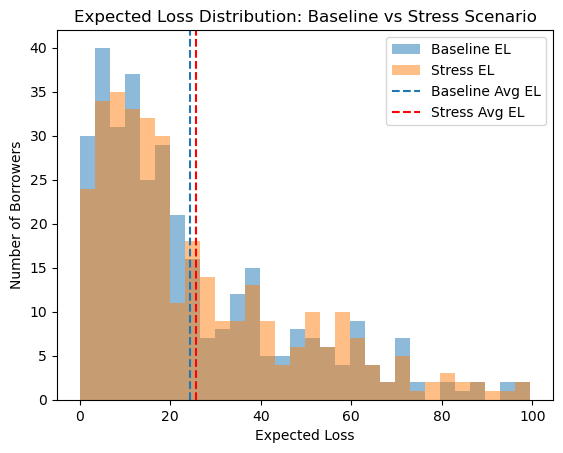

In [52]:
plt.hist(stress_data_results["EL_baseline"], bins=30, alpha=0.5, label="Baseline EL")
plt.hist(stress_data_results["Stressed_EL"], bins=30, alpha=0.5, label="Stress EL")

plt.axvline(stress_data_results["EL_baseline"].mean(), linestyle="--", label="Baseline Avg EL")
plt.axvline(stress_data_results["Stressed_EL"].mean(), linestyle="--", color="red", label="Stress Avg EL")

plt.xlabel("Expected Loss")
plt.ylabel("Number of Borrowers")
plt.title("Expected Loss Distribution: Baseline vs Stress Scenario")

plt.legend()
plt.show()

Histogram interpretation:
 - Baseline: The baseline scenario shows most borrowers concentrated in lower expected loss ranges, indicating relatively stable credit risk conditions.
 - Stress: Under the stress scenario, the expected loss distribution shifts slightly to the right with a higher average EL, indicating increased potential credit losses across the portfolio but still relatively stable conditions.

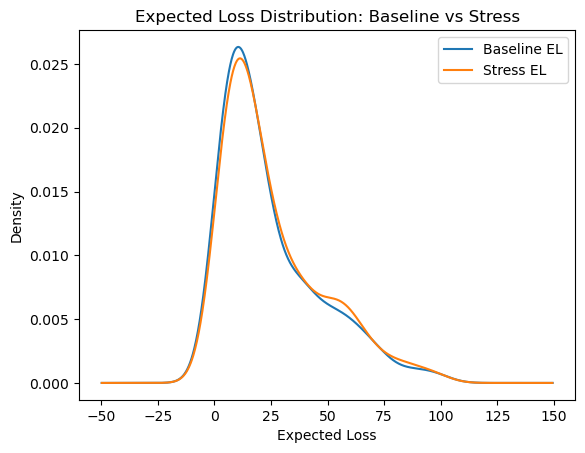

In [53]:
plt.figure()

stress_data_results["EL_baseline"].plot(kind="density", label="Baseline EL")
stress_data_results["Stressed_EL"].plot(kind="density", label="Stress EL")

plt.xlabel("Expected Loss")
plt.ylabel("Density")
plt.title("Expected Loss Distribution: Baseline vs Stress")

plt.legend()
plt.show()

   - Baseline: The baseline expected loss distribution is concentrated at lower values, indicating relatively stable credit risk and lower potential portfolio losses under normal conditions.

   - Stress: Under the stress scenario, the distribution shifts slightly toward higher expected loss values, suggesting an increase in potential credit losses due to change financial conditions.

## Expected Loss Migration Matrix

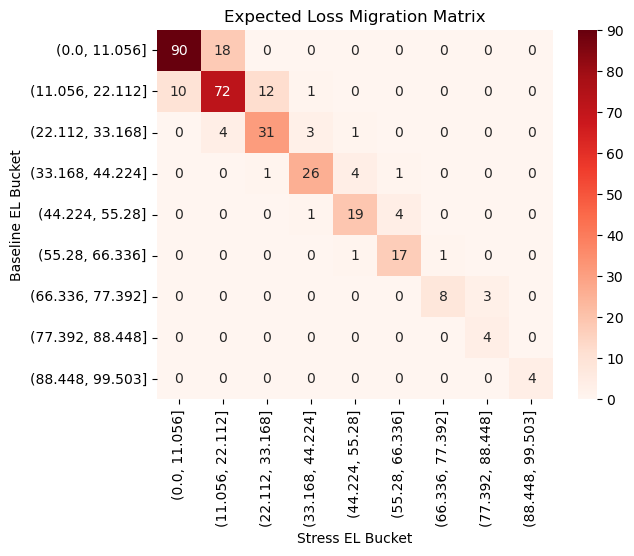

In [54]:
# Migration Matrix

bins = np.linspace(
    stress_data_results["EL_baseline"].min(),
    stress_data_results["Stressed_EL"].max(),
    10
)

stress_data_results["baseline_bucket"] = pd.cut(stress_data_results["EL_baseline"], bins)
stress_data_results["stress_bucket"] = pd.cut(stress_data_results["Stressed_EL"], bins)

migration = pd.crosstab(
    stress_data_results["baseline_bucket"],
    stress_data_results["stress_bucket"]
)

plt.figure()

sns.heatmap(migration, annot=True, fmt="d", cmap="Reds")

plt.title("Expected Loss Migration Matrix")
plt.xlabel("Stress EL Bucket")
plt.ylabel("Baseline EL Bucket")

plt.show()

- Most firms remain in the same expected loss box under both baseline and stress scenarios, indicating that the overall portfolio risk structure remains relatively stable.

- A small number of firms move to higher expected loss buckets under stress, showing that worsening financial conditions increase potential credit losses for some borrowers.

## Top Borrowers with Largest Expected Loss Increase

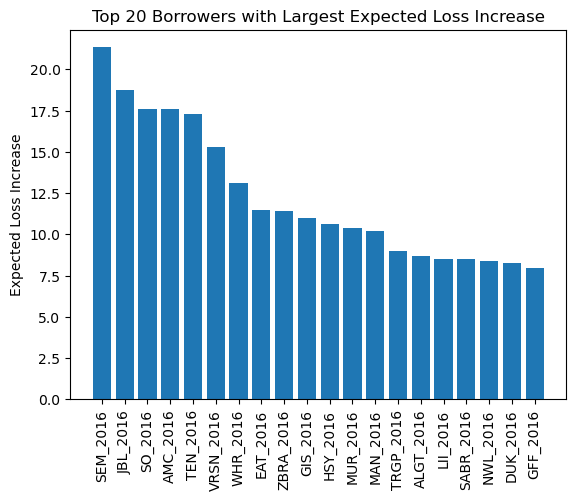

In [55]:
# Top Borrowers woth Largest Expected Loss Increase

top_risk = stress_data_results.sort_values("Stressed_EL_change", ascending=False).head(20)

plt.figure()

plt.bar(range(len(top_risk)), top_risk["Stressed_EL_change"])

plt.xticks(range(len(top_risk)), top_risk.index, rotation=90)

plt.ylabel("Expected Loss Increase")
plt.title("Top 20 Borrowers with Largest Expected Loss Increase")

plt.show()

- The borrowers SEM_2016, JBL_2016, SPC_2016, AMC_2016, and TEN_2016 show the largest increases in expected loss under the stress scenario, indicating they contribute most to the rise in portfolio credit risk.

## Sector-wise EL change under Stress

In [56]:
# Sector wise difference
sector_analysis = stress_data_results.groupby("Sector").agg({
    "EL_baseline": "mean",
    "Stressed_EL": "mean",
    "Stressed_EL_change": "mean",
    "Stressed_EL_percentage": "mean"
}).sort_values("Stressed_EL_percentage", ascending=False)

sector_analysis.style.background_gradient().format("{:.2f}")

,EL_baseline,Stressed_EL,Stressed_EL_change,Stressed_EL_percentage
Sector,,,,
Consumer Non-Durables,12.85,14.37,1.52,31.14
Transportation,15.15,16.81,1.66,24.68
Health Care,17.51,19.66,2.15,19.83
Capital Goods,17.67,19.08,1.41,19.62
Consumer Durables,43.73,47.00,3.27,15.10
Public Utilities,22.67,24.67,1.99,14.42
Technology,23.69,25.43,1.74,12.60
Finance,8.35,9.10,0.75,11.96
Consumer Services,30.86,32.44,1.58,10.82


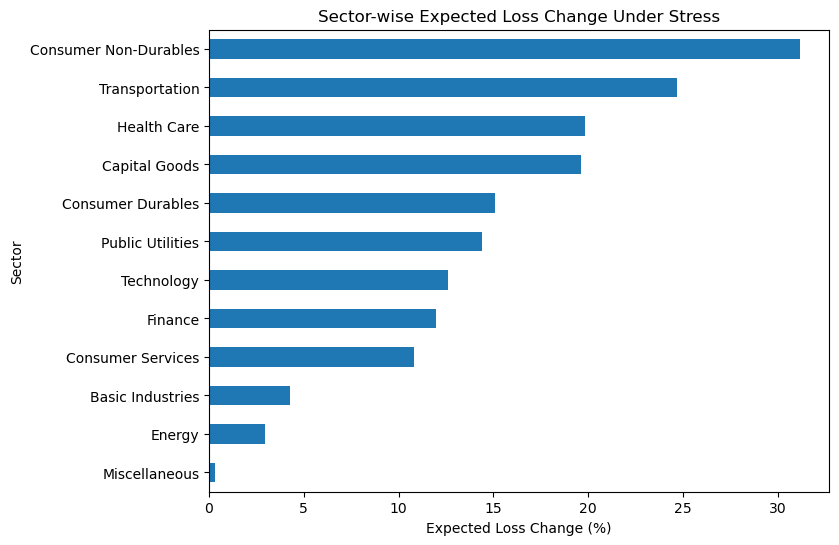

In [57]:
sector_analysis = sector_analysis.sort_values("Stressed_EL_percentage", ascending=True)

plt.figure(figsize=(8,6))

sector_analysis["Stressed_EL_percentage"].plot(kind="barh")

plt.xlabel("Expected Loss Change (%)")
plt.ylabel("Sector")
plt.title("Sector-wise Expected Loss Change Under Stress")

plt.show()

**High Pecentage of Expected Loss Increase**
 - Consumer Non-Durables, Transportation, and Health Care show the largest increases in expected loss under the stress scenario, indicating that firms in these sectors are more sensitive to deteriorating financial conditions, where higher default probabilities significantly increase potential credit losses.

**Low Pecentage of Expected Loss Increase**
 - Miscellaneous, Energy, and Basic Industries show the smallest changes in expected loss, suggesting that firms in these sectors are relatively less affected by the stress scenario, either due to stable financial structures or limited changes in predicted default risk.

# **Model Conclusion**

**Proxy target variable**: Credit ratings were used as a proxy for default risk instead of actual default events, which may not fully capture true default behavior.

**Proxy variables for LGD and EAD**: Due to limited data availability, Debt Ratio was used as an LGD proxy and Current Ratio as an EAD proxy, which may not perfectly represent actual exposure and recovery rates.

**Limited data scope**: The model can distinguish between high-risk and low-risk firms reasonably well, but its predictive performance may improve with more detailed financial information and real default data.